<h1 style="color:blue">Aujourd'hui on entre dans la Phase 2 — Data Analysis & Statistiques ! C'est là que tes bases en maths vont vraiment briller ! 🎯</h1>

<h2 style="color: red"><b>🎯 Objectif du jour</b></h2>
<h3><b> Maîtriser les statistiques descriptives et la visualisation avancée pour extraire des insights business pertinents.</b></h3>

<h4><b>Statistiques descriptives approfondies.</b></h4>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Style des graphiques
sns.set_theme(style="whitegrid", palette="husl")

np.random.seed(42)

# Dataset : salaires d'une entreprise camerounaise
n = 200
df = pd.DataFrame({
    "employe_id": range(1, n+1),
    "age": np.random.randint(22, 60, n),
    "salaire": np.concatenate([
        np.random.normal(350000, 80000, 150),   # 150 employés normaux
        np.random.normal(1200000, 200000, 50)   # 50 cadres supérieurs
    ]),
    "departement": np.random.choice(["Tech", "Marketing", "RH", "Finance", "Ventes"], n),
    "experience": np.random.randint(1, 35, n),
    "performance": np.random.randint(1, 6, n)
})

df["salaire"] = df["salaire"].astype(int).clip(lower=80000)

print("=== APERÇU DU DATASET ===")
print(df.head())
print(f"\nShape : {df.shape}")

=== APERÇU DU DATASET ===
   employe_id  age  salaire departement  experience  performance
0           1   50   384241          RH          29            4
1           2   36   152424      Ventes          32            3
2           3   29   388558        Tech          19            2
3           4   42   424116     Finance          21            2
4           5   40   282993        Tech           5            3

Shape : (200, 6)


<p><b>On crée deux groupes de salaires — des employés normaux et des cadres supérieurs.<br> C'est volontaire pour simuler une distribution bimodale que tu vas découvrir dans quelques minutes !</b></p>

<h4><b>Mesures de tendance centrale :</b></h4>

In [4]:
salaires = df["salaire"]

print("=== MESURES DE TENDANCE CENTRALE ===")
print(f"Moyenne    : {salaires.mean():,.0f} FCFA")
print(f"Médiane    : {salaires.median():,.0f} FCFA")
print(f"Mode       : {salaires.mode()[0]:,.0f} FCFA")

print("\n=== MESURES DE DISPERSION ===")
print(f"Écart-type : {salaires.std():,.0f} FCFA")
print(f"Variance   : {salaires.var():,.0f}")
print(f"Min        : {salaires.min():,.0f} FCFA")
print(f"Max        : {salaires.max():,.0f} FCFA")
print(f"Étendue    : {salaires.max() - salaires.min():,.0f} FCFA")

print("\n=== QUARTILES ===")
print(f"Q1 (25%)   : {salaires.quantile(0.25):,.0f} FCFA")
print(f"Q2 (50%)   : {salaires.quantile(0.50):,.0f} FCFA")
print(f"Q3 (75%)   : {salaires.quantile(0.75):,.0f} FCFA")
print(f"IQR        : {salaires.quantile(0.75) - salaires.quantile(0.25):,.0f} FCFA")

print("\n=== FORME DE LA DISTRIBUTION ===")
print(f"Skewness   : {salaires.skew():.3f}")
print(f"Kurtosis   : {salaires.kurtosis():.3f}")

=== MESURES DE TENDANCE CENTRALE ===
Moyenne    : 558,143 FCFA
Médiane    : 384,013 FCFA
Mode       : 119,643 FCFA

=== MESURES DE DISPERSION ===
Écart-type : 390,260 FCFA
Variance   : 152,302,915,859
Min        : 119,643 FCFA
Max        : 1,628,641 FCFA
Étendue    : 1,508,998 FCFA

=== QUARTILES ===
Q1 (25%)   : 309,151 FCFA
Q2 (50%)   : 384,013 FCFA
Q3 (75%)   : 550,141 FCFA
IQR        : 240,990 FCFA

=== FORME DE LA DISTRIBUTION ===
Skewness   : 1.312
Kurtosis   : 0.240


<h4><b style="color:red">💡 Skewness et Kurtosis — deux mesures que tu verras tout le temps en data science :</b></h4>
<ul>
<li>Skewness > 0 → distribution asymétrique à droite (queue à droite)</li>
<li>Skewness < 0 → distribution asymétrique à gauche</li>
<li>Kurtosis > 0 → distribution plus pointue que la normale (leptokurtique)</li>
<li>Kurtosis < 0 → distribution plus plate que la normale (platykurtique)</li>
    </ul>

<h4 style="color:red">Excellente observation ! 🎉 Et tu sais déjà pourquoi !</h4>

<p>La moyenne est très supérieure à la médiane parce que les 50 cadres supérieurs avec des salaires <br> autour de 1 200 000 FCFA tirent la moyenne vers le haut — exactement ce qu'on appelle une distribution asymétrique à droite (skewness positif) !</P>

<b>💡 Ce que ça dit en pratique :</b> <br>
<ul>
<li>Si ton patron dit "le salaire moyen dans notre entreprise est de X" → il inclut les cadres supérieurs qui gonflent le chiffre</li>
<li>La médiane est bien plus représentative du salaire d'un employé typique</li>
<li>C'est pour ça que les économistes utilisent toujours la médiane pour parler des revenus des ménages !</li>
</ul>

<h4><b> Visualiser la distribution :<b></h4>

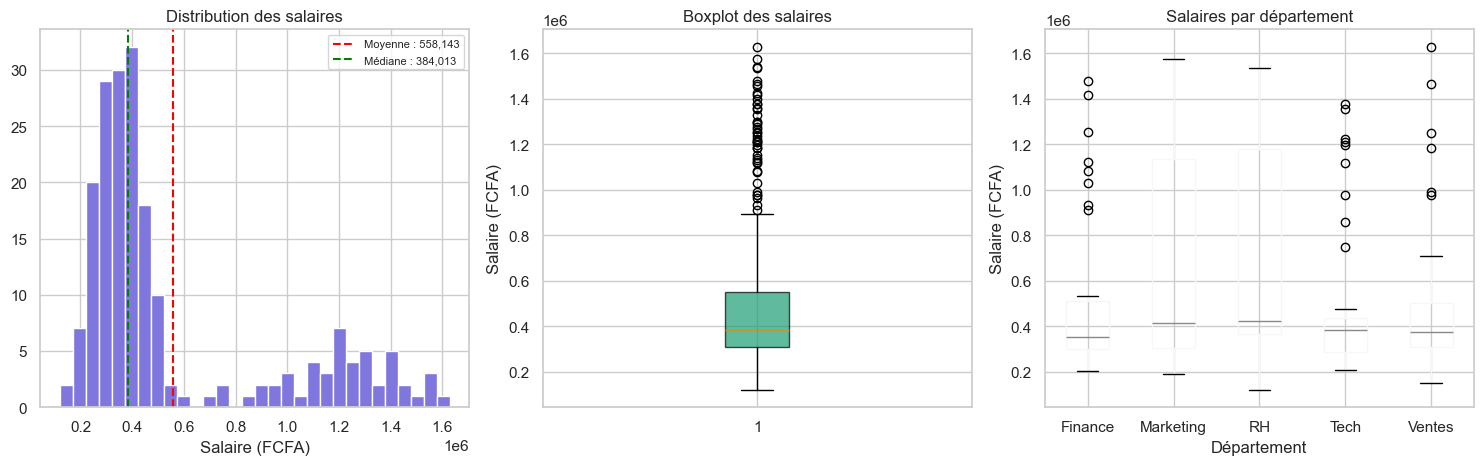

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Histogramme
axes[0].hist(salaires, bins=30, color="#7F77DD", edgecolor="white")
axes[0].axvline(salaires.mean(), color="red", linestyle="--", 
                label=f"Moyenne : {salaires.mean():,.0f}")
axes[0].axvline(salaires.median(), color="green", linestyle="--",
                label=f"Médiane : {salaires.median():,.0f}")
axes[0].set_title("Distribution des salaires")
axes[0].set_xlabel("Salaire (FCFA)")
axes[0].legend(fontsize=8)

# 2. Boxplot
axes[1].boxplot(salaires, patch_artist=True,
                boxprops=dict(facecolor="#1D9E75", alpha=0.7))
axes[1].set_title("Boxplot des salaires")
axes[1].set_ylabel("Salaire (FCFA)")

# 3. Boxplot par département
df.boxplot(column="salaire", by="departement", ax=axes[2])
axes[2].set_title("Salaires par département")
axes[2].set_xlabel("Département")
axes[2].set_ylabel("Salaire (FCFA)")

plt.suptitle("")
plt.tight_layout()
plt.show()

<p>💡 Les lignes verticales sur l'histogramme montrent visuellement l'écart entre moyenne (rouge) et médiane (verte)<br> — tu vas voir clairement que la moyenne est tirée vers la droite par les hauts salaires !</p>

<p>Sur le boxplot par département — les boîtes semblent <b style="color: red">"disparaître" </b> car les outliers (cadres supérieurs) écrasent l'échelle. Les boîtes existent mais paraissent très petites comparées aux points extrêmes !
Pour mieux voir, on peut limiter l'axe Y :</p>

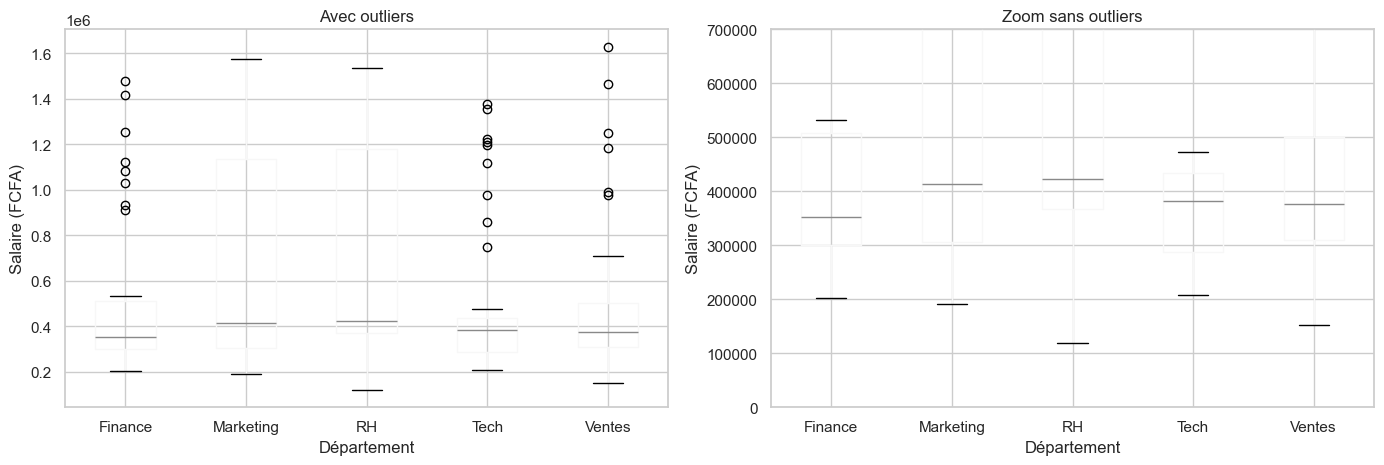

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot par département SANS limite
df.boxplot(column="salaire", by="departement", ax=axes[0])
axes[0].set_title("Avec outliers")
axes[0].set_xlabel("Département")
axes[0].set_ylabel("Salaire (FCFA)")

# Boxplot par département AVEC limite — on zoom sur les employés normaux
df.boxplot(column="salaire", by="departement", ax=axes[1])
axes[1].set_ylim(0, 700000)  # ← on zoome
axes[1].set_title("Zoom sans outliers")
axes[1].set_xlabel("Département")
axes[1].set_ylabel("Salaire (FCFA)")

plt.suptitle("")
plt.tight_layout()
plt.show()

<p><b>💡 Leçon importante : </b><br>les outliers peuvent masquer visuellement la distribution principale. C'est pour ça qu'en data science on fait toujours deux analyses — avec et sans outliers — pour avoir une vision complète !</p>

<h4><b> Statistiques par groupe :<b></h4>

In [9]:
# Statistiques complètes par département
stats_dept = df.groupby("departement")["salaire"].agg([
    ("Moyenne", "mean"),
    ("Médiane", "median"),
    ("Écart-type", "std"),
    ("Min", "min"),
    ("Max", "max"),
    ("Effectif", "count")
]).round(0)

print("=== STATISTIQUES PAR DÉPARTEMENT ===")
print(stats_dept.to_string())

# Quel département paie le mieux ?
print(f"\nMeilleur département (médiane) : {df.groupby('departement')['salaire'].median().idxmax()}")

# Corrélation âge/salaire et expérience/salaire
print("\n=== CORRÉLATIONS ===")
print(f"Corrélation âge-salaire        : {df['age'].corr(df['salaire']):.3f}")
print(f"Corrélation expérience-salaire : {df['experience'].corr(df['salaire']):.3f}")
print(f"Corrélation performance-salaire: {df['performance'].corr(df['salaire']):.3f}")

=== STATISTIQUES PAR DÉPARTEMENT ===
              Moyenne   Médiane  Écart-type     Min      Max  Effectif
departement                                                           
Finance      509788.0  352324.0    357849.0  202015  1477913        38
Marketing    646619.0  412948.0    464632.0  190752  1574084        36
RH           676972.0  422596.0    434713.0  119643  1535058        38
Tech         496486.0  381741.0    342970.0  207339  1377240        43
Ventes       486765.0  376177.0    329665.0  152424  1628641        45

Meilleur département (médiane) : RH

=== CORRÉLATIONS ===
Corrélation âge-salaire        : -0.037
Corrélation expérience-salaire : 0.025
Corrélation performance-salaire: 0.016


<p><b>Corrélation âge-salaire (-0.037) :</b><br>
Correct ! Mais attention — une corrélation de -0.037 est quasi nulle. On ne peut pas vraiment dire que l'âge <br> fait baisser le salaire — il n'y a simplement pas de relation linéaire entre les deux !<br>
<b>Corrélation expérience-salaire (0.025) :</b><br>
Correct ! Mais là aussi 0.025 est quasi nulle — l'expérience n'explique presque pas le salaire dans ce dataset.<br>
<b>Corrélation performance-salaire (0.016) :</b><br>
Même chose — relation quasi inexistante.</p>

<h4 style="color:black">Visualiser les corrélations :</h4> 

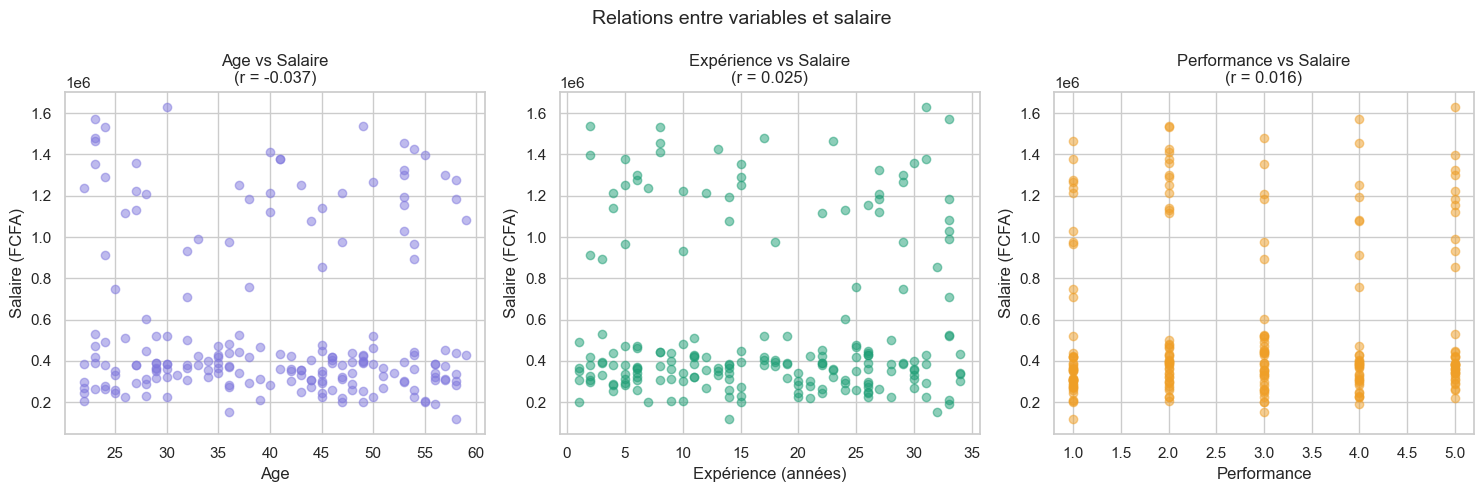

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Age vs Salaire
axes[0].scatter(df["age"], df["salaire"], 
                alpha=0.5, color="#7F77DD")
axes[0].set_title(f"Age vs Salaire\n(r = {df['age'].corr(df['salaire']):.3f})")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Salaire (FCFA)")

# 2. Expérience vs Salaire
axes[1].scatter(df["experience"], df["salaire"],
                alpha=0.5, color="#1D9E75")
axes[1].set_title(f"Expérience vs Salaire\n(r = {df['experience'].corr(df['salaire']):.3f})")
axes[1].set_xlabel("Expérience (années)")
axes[1].set_ylabel("Salaire (FCFA)")

# 3. Performance vs Salaire
axes[2].scatter(df["performance"], df["salaire"],
                alpha=0.5, color="#EF9F27")
axes[2].set_title(f"Performance vs Salaire\n(r = {df['performance'].corr(df['salaire']):.3f})")
axes[2].set_xlabel("Performance")
axes[2].set_ylabel("Salaire (FCFA)")

plt.suptitle("Relations entre variables et salaire", fontsize=14)
plt.tight_layout()
plt.show()

<p>💡 Le scatter plot est le graphique parfait pour visualiser une corrélation — si les points forment une ligne droite <br> c'est une forte corrélation, s'ils sont dispersés en nuage c'est une corrélation faible !</p>

<p>Des points dispersés sans forme particulière = corrélation nulle — c'est la preuve visuelle que ces variables n'ont pas de relation linéaire entre elles !</p>

<h3><b>Distributions et probabilités !</b></h3>

<h4><b>Les distributions de probabilités :</b></h4>

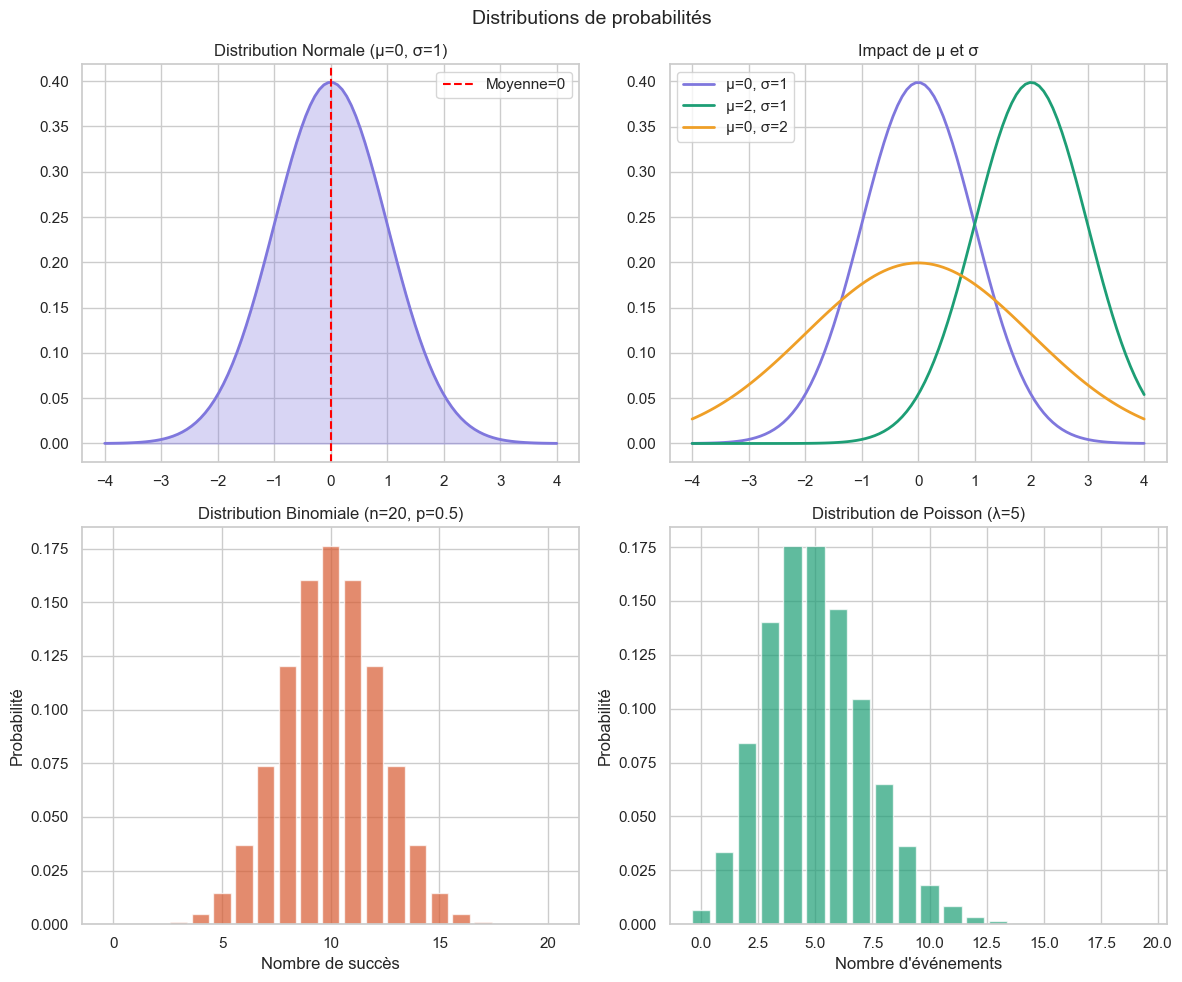

In [11]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

x = np.linspace(-4, 4, 100)

# 1. Distribution Normale
axes[0,0].plot(x, stats.norm.pdf(x), color="#7F77DD", linewidth=2)
axes[0,0].fill_between(x, stats.norm.pdf(x), alpha=0.3, color="#7F77DD")
axes[0,0].axvline(0, color="red", linestyle="--", label="Moyenne=0")
axes[0,0].set_title("Distribution Normale (μ=0, σ=1)")
axes[0,0].legend()

# 2. Effet de la moyenne et l'écart-type
for mu, sigma, color in [(0, 1, "#7F77DD"), (2, 1, "#1D9E75"), (0, 2, "#EF9F27")]:
    axes[0,1].plot(x, stats.norm.pdf(x, mu, sigma), 
                   label=f"μ={mu}, σ={sigma}", linewidth=2, color=color)
axes[0,1].set_title("Impact de μ et σ")
axes[0,1].legend()

# 3. Distribution Binomiale
k = np.arange(0, 21)
binom_probs = stats.binom.pmf(k, n=20, p=0.5)
axes[1,0].bar(k, binom_probs, color="#D85A30", alpha=0.7)
axes[1,0].set_title("Distribution Binomiale (n=20, p=0.5)")
axes[1,0].set_xlabel("Nombre de succès")
axes[1,0].set_ylabel("Probabilité")

# 4. Distribution de Poisson
k = np.arange(0, 20)
poisson_probs = stats.poisson.pmf(k, mu=5)
axes[1,1].bar(k, poisson_probs, color="#1D9E75", alpha=0.7)
axes[1,1].set_title("Distribution de Poisson (λ=5)")
axes[1,1].set_xlabel("Nombre d'événements")
axes[1,1].set_ylabel("Probabilité")

plt.suptitle("Distributions de probabilités", fontsize=14)
plt.tight_layout()
plt.show()

<h4> <b>💡 Ces 3 distributions sont fondamentales en data science :</b></h4>
<ul>
<li>Normale → salaires, tailles, erreurs de mesure </li>
<li>Binomiale → taux de conversion, succès/échec</li>
<li>Poisson → nombre de clients par heure, nombre de pannes</li></ul>

<h4><b>Tester la normalité de nos données :</b></h4>

=== TEST DE NORMALITÉ (Shapiro-Wilk) ===
Statistique : 0.8004
P-value     : 0.000001
Conclusion : Distribution NON NORMALE (p < 0.05)


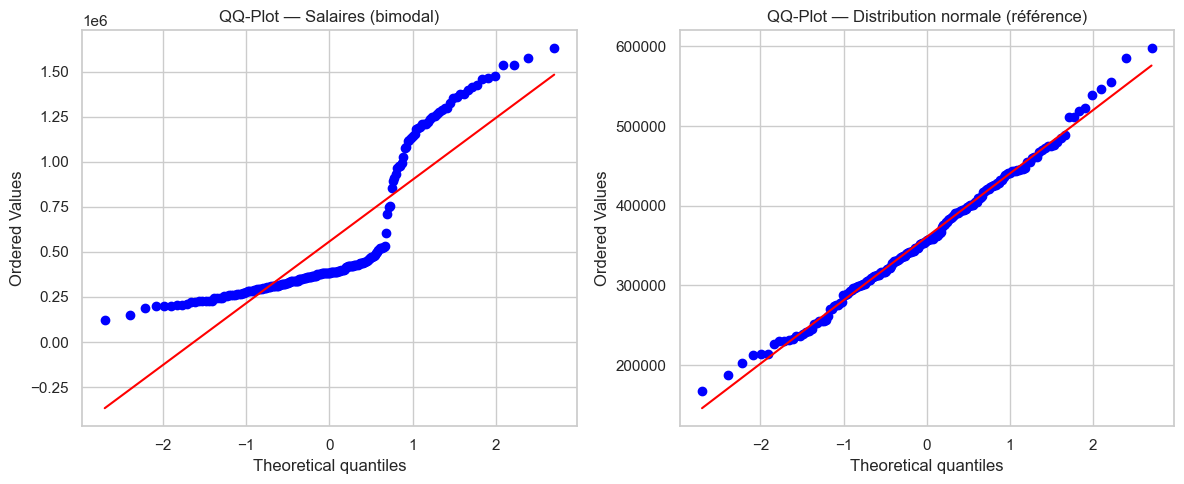


=== INTERPRÉTATION QQ-PLOT ===
Points sur la ligne droite = distribution normale
Points qui s'écartent = distribution non normale


In [12]:
from scipy import stats

# Test de normalité de Shapiro-Wilk
stat, p_value = stats.shapiro(df["salaire"].sample(50))  # échantillon de 50
print("=== TEST DE NORMALITÉ (Shapiro-Wilk) ===")
print(f"Statistique : {stat:.4f}")
print(f"P-value     : {p_value:.6f}")

if p_value > 0.05:
    print("Conclusion : Distribution NORMALE (p > 0.05)")
else:
    print("Conclusion : Distribution NON NORMALE (p < 0.05)")

# QQ-Plot — visualiser la normalité
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# QQ-Plot des salaires
stats.probplot(df["salaire"], dist="norm", plot=axes[0])
axes[0].set_title("QQ-Plot — Salaires (bimodal)")

# QQ-Plot d'une distribution normale pour comparaison
normale = np.random.normal(350000, 80000, 200)
stats.probplot(normale, dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot — Distribution normale (référence)")

plt.tight_layout()
plt.show()

print("\n=== INTERPRÉTATION QQ-PLOT ===")
print("Points sur la ligne droite = distribution normale")
print("Points qui s'écartent = distribution non normale")

<p>💡 Le QQ-Plot est l'outil visuel standard pour tester la normalité — si les points suivent la ligne droite, la distribution est normale.<br> Tu verras clairement la différence entre nos salaires bimodaux et une vraie distribution normale !</p>

<p><h5>💡 Pourquoi c'est important en Machine Learning ? </h5>
Beaucoup d'algorithmes (régression linéaire, tests statistiques) supposent que les données suivent une distribution normale. <br>Si ce n'est pas le cas, il faut transformer les données — par exemple avec un logarithme :</p>

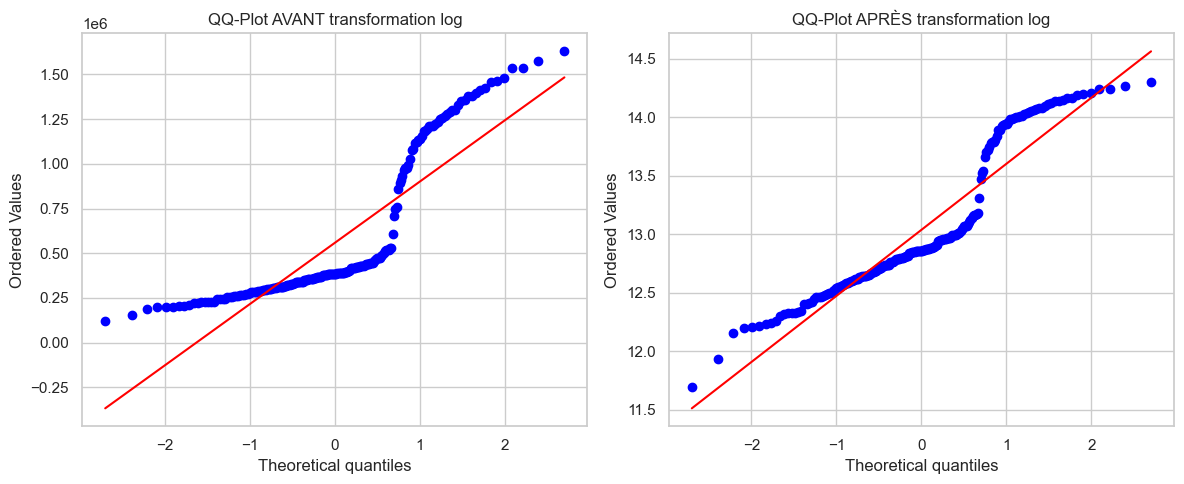

In [13]:
# Transformer les salaires avec log pour les normaliser
df["salaire_log"] = np.log(df["salaire"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Avant transformation
stats.probplot(df["salaire"], dist="norm", plot=axes[0])
axes[0].set_title("QQ-Plot AVANT transformation log")

# Après transformation
stats.probplot(df["salaire_log"], dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot APRÈS transformation log")

plt.tight_layout()
plt.show()

<p><h5><b>💡 Pourquoi le log ne suffit pas ici ?</b></h5>
Notre distribution est bimodale (deux bosses) — employés normaux + cadres supérieurs.<br> Le logarithme corrige l'asymétrie mais ne peut pas fusionner deux groupes distincts. Dans ce cas la meilleure solution serait d'analyser les deux groupes séparément !<br></p>

<h3><b>Visualisation avancée avec Seaborn !</b></h3>

<h4><b>Les graphiques Seaborn essentiels :</b></h4>

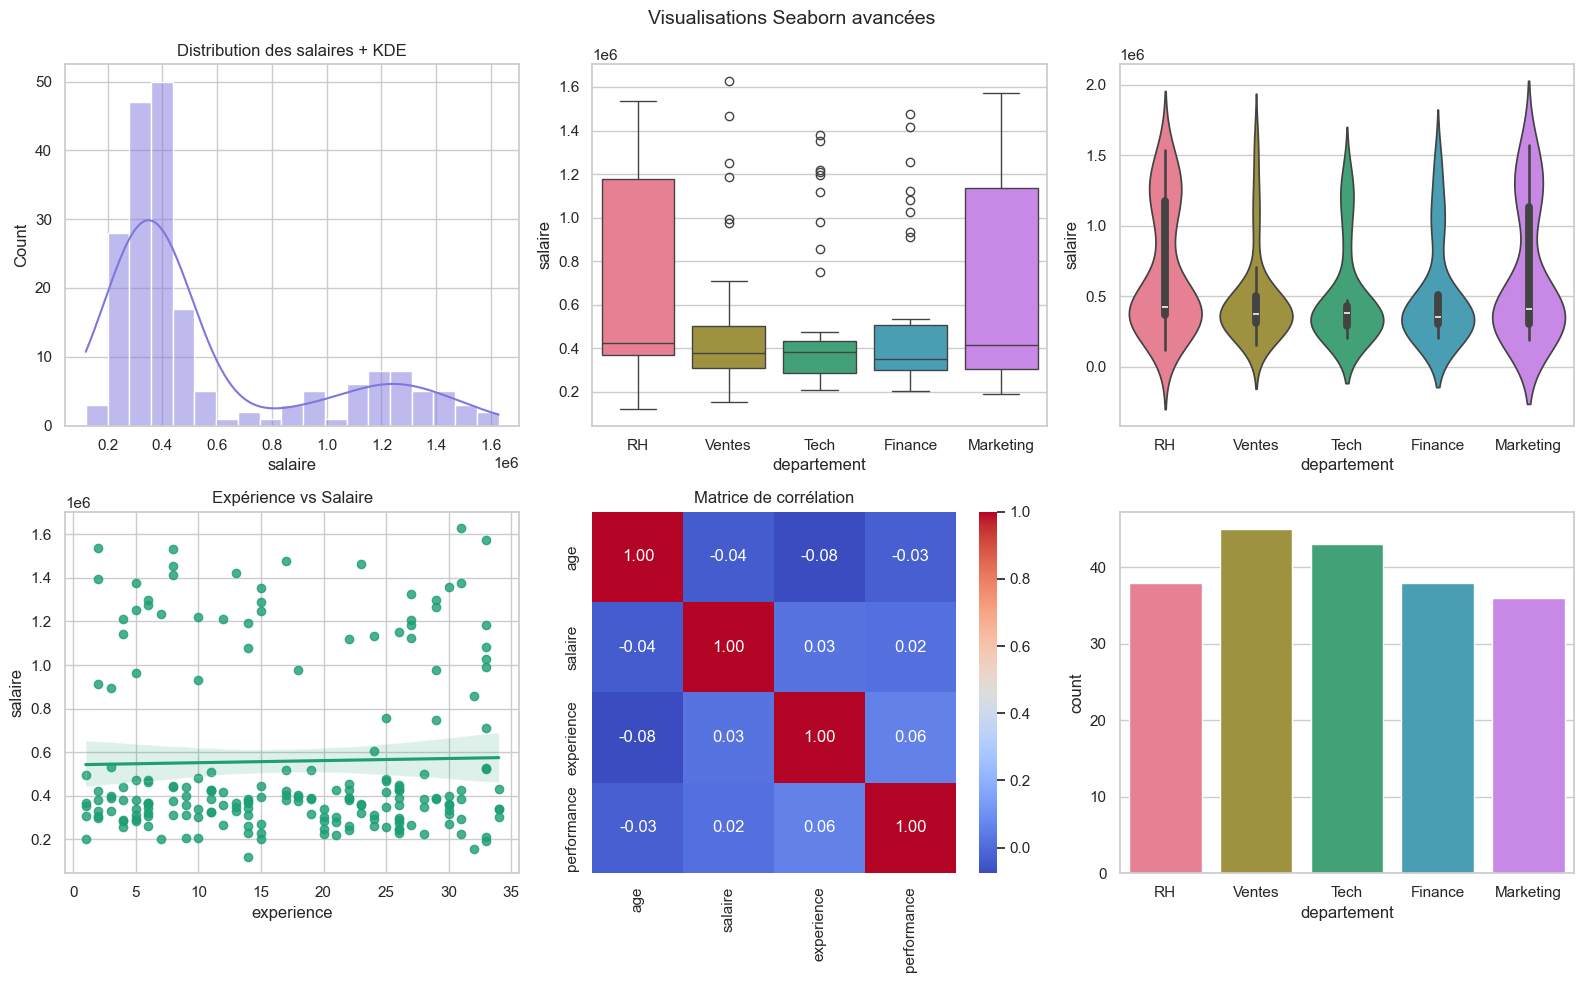

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Histogramme avec courbe de densité (KDE)
sns.histplot(data=df, x="salaire", kde=True, 
             color="#7F77DD", ax=axes[0,0])
axes[0,0].set_title("Distribution des salaires + KDE")

# 2. Boxplot par département
sns.boxplot(data=df, x="departement", y="salaire",
            hue="departement", legend=False,
            palette="husl", ax=axes[0,1])

# 3. Violinplot
sns.violinplot(data=df, x="departement", y="salaire",
               hue="departement", legend=False,
               palette="husl", ax=axes[0,2])

# 4. Scatterplot avec régression
sns.regplot(data=df, x="experience", y="salaire",
            color="#1D9E75", ax=axes[1,0])
axes[1,0].set_title("Expérience vs Salaire")

# 5. Heatmap de corrélation
corr_matrix = df[["age", "salaire", "experience", "performance"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", 
            cmap="coolwarm", ax=axes[1,1])
axes[1,1].set_title("Matrice de corrélation")

# 6. Countplot
sns.countplot(data=df, x="departement",
              hue="departement", legend=False,
              palette="husl", ax=axes[1,2])

plt.suptitle("Visualisations Seaborn avancées", fontsize=14)
plt.tight_layout()
plt.show()

<p>💡 Le violin plot combine le boxplot et la distribution KDE — il montre à la fois les quartiles ET <br>la forme de la distribution. C'est très utile pour voir si une distribution est bimodale comme nos salaires !</p>
<p>💡 En Machine Learning, on utilise cette matrice pour détecter la multicolinéarité — si deux variables ont une corrélation > 0.8, <br>on en supprime une car elles donnent la même information au modèle !</p>

<h4><b>Pairplot et analyse multivariée :</b></h4>

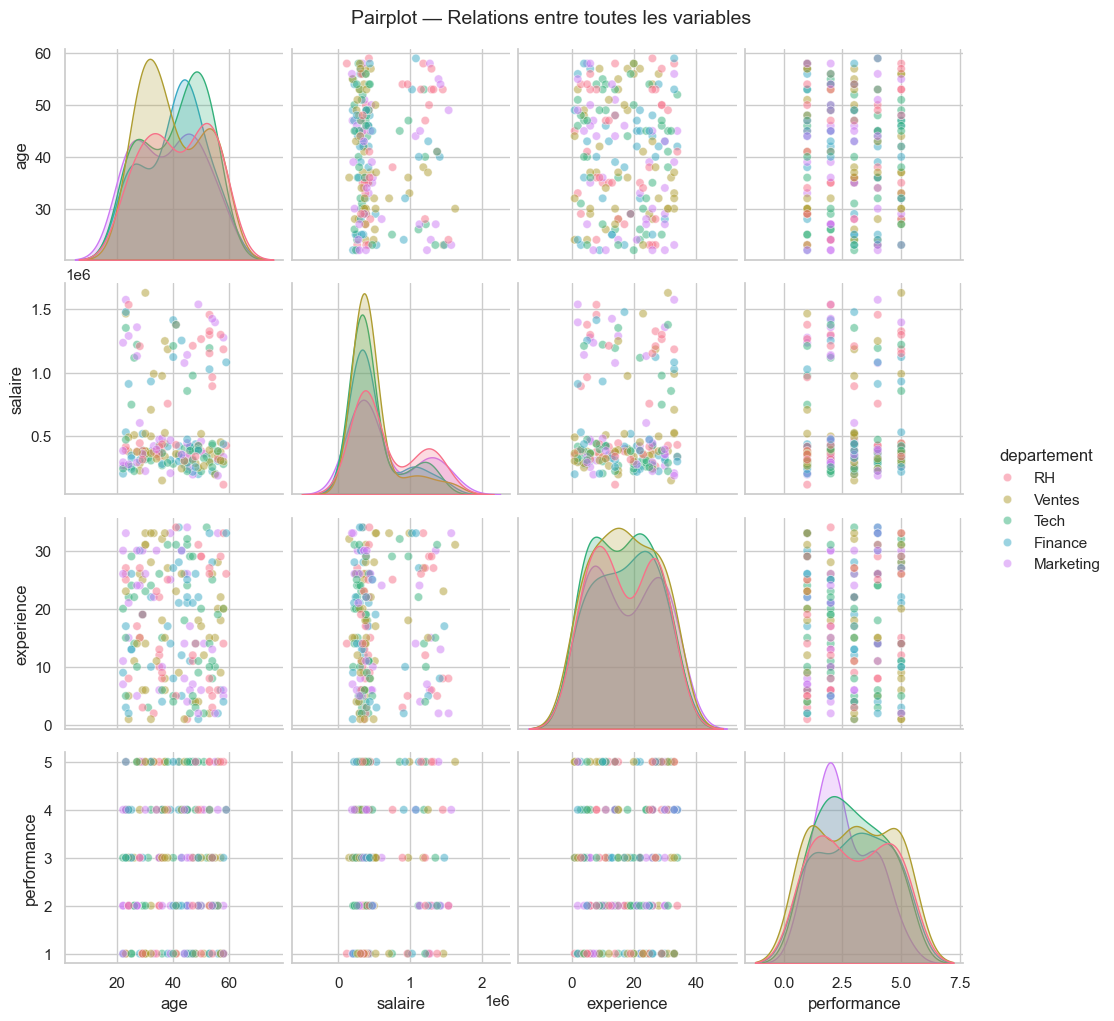

In [16]:
# Pairplot — visualiser toutes les relations en une fois
g = sns.pairplot(df[["age", "salaire", "experience", "performance", "departement"]], 
                 hue="departement",
                 palette="husl",
                 diag_kind="kde",
                 plot_kws={"alpha": 0.5})

g.fig.suptitle("Pairplot — Relations entre toutes les variables", 
               y=1.02, fontsize=14)
plt.show()

<p> <b>💡 Le pairplot </b>est l'outil d'exploration le plus puissant en data science — il trace toutes les relations entre toutes les variables en une seule commande :
<ul>
<li>Diagonale → distribution de chaque variable (KDE)</li>
<li>Hors diagonale → scatter plot entre chaque paire de variables</li>
<li>Couleurs → différencient les départements</li </ul> </p>

<p>
<h5>Ce que tu observes :</h5>
<ul>
<li>Diagonale → KDE plot (courbe de densité) — montre la distribution de chaque variable avec elle-même</li>
<li>Hors diagonale → Scatter plot — montre la relation entre deux variables différentes, coloré par département</li>
</ul>
<h5>💡 Ce que le pairplot te révèle en un coup d'œil :</h5>
<ul>
<li>Les scatter plots sans forme → pas de corrélation (ce qu'on avait calculé)</li>
<li>Les KDE plots avec deux bosses → confirme la distribution bimodale des salaires (employés + cadres)</li>
<li>Les couleurs mélangées → les départements ne sont pas bien séparés, ils ont des profils similaires</li>
</ul>    
</p>

<h2><b> Exercice pratique ! 💪</b></h2>

<h3>Contexte : Tu es data scientist dans une entreprise de télécommunications camerounaise. Voici ton dataset :<h3>

=== STATISTIQUES DESCRIPTIVE ===
             age  anciennete  consommation_data  facture  appels_par_mois  satisfaction  churn
Moyenne     43.0         7.0                5.0  14765.0             45.0           3.0    0.0
Médiane     44.0         7.0                3.0  15042.0             45.0           3.0    0.0
Écart-type  15.0         4.0                6.0   5245.0              7.0           1.0    0.0
Skewness    -0.0         0.0                2.0     -0.0             -0.0          -0.0    1.0
Kurtosis    -1.0        -1.0                7.0     -0.0             -0.0          -1.0   -1.0
=== TEST DE NORMALITÉ (Shapiro-Wilk) ===
Variable: facture            | p-value: 0.0546
   -> Distribution probablement normale (On ne rejette pas H0)
Variable: consommation_data  | p-value: 0.0001
   -> Distribution non normale (On rejette H0)
======= Matrice de correlation======


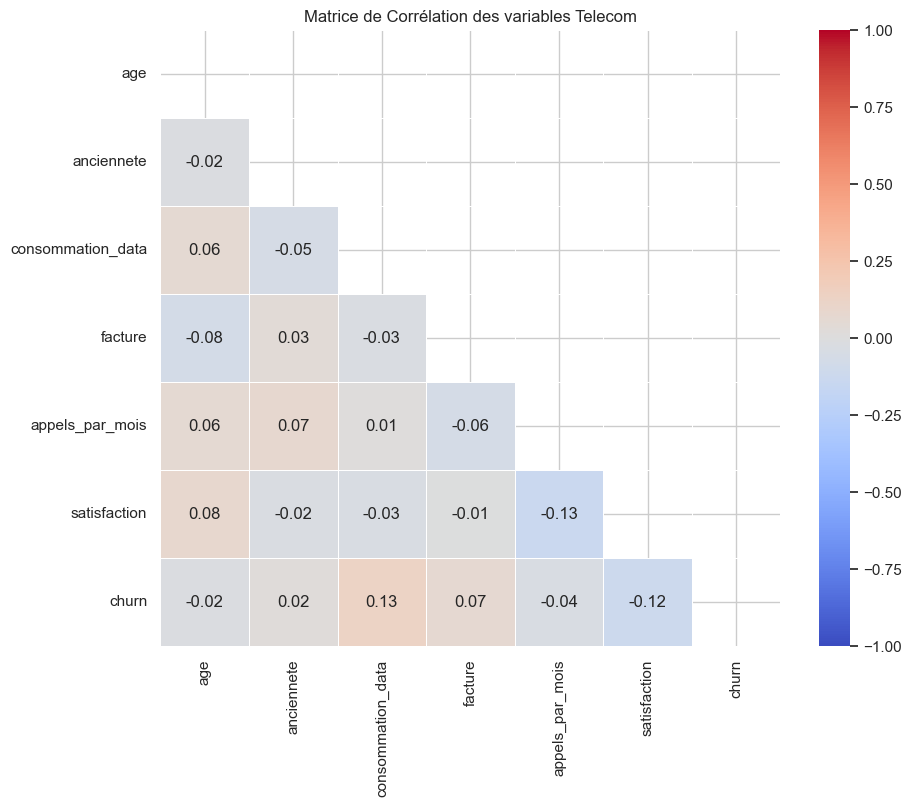

====identifie les relations les plus fortes====
 Tous les coefficients sont inférieurs à 0.2 en valeur absolue donc pas de forte correlation
          count  mean  median  std
forfait                           
Basique      95   0.0     0.0  0.0
Premium     104   0.0     0.0  0.0
Standard    101   0.0     0.0  0.0


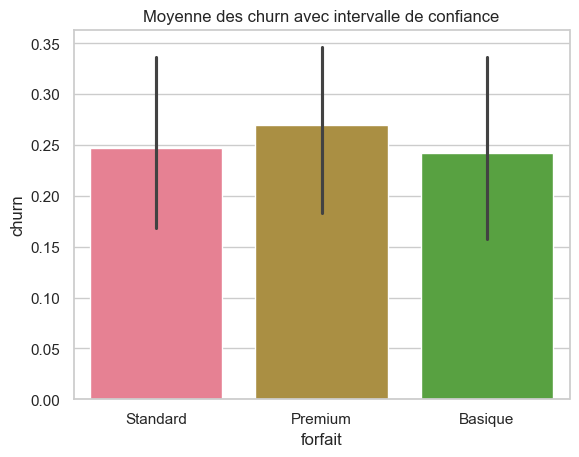

Au regard du graphique le churn est plus elevé au niveau du forfait premium donc il parait que que c'est le forfait quiperd le plus de client


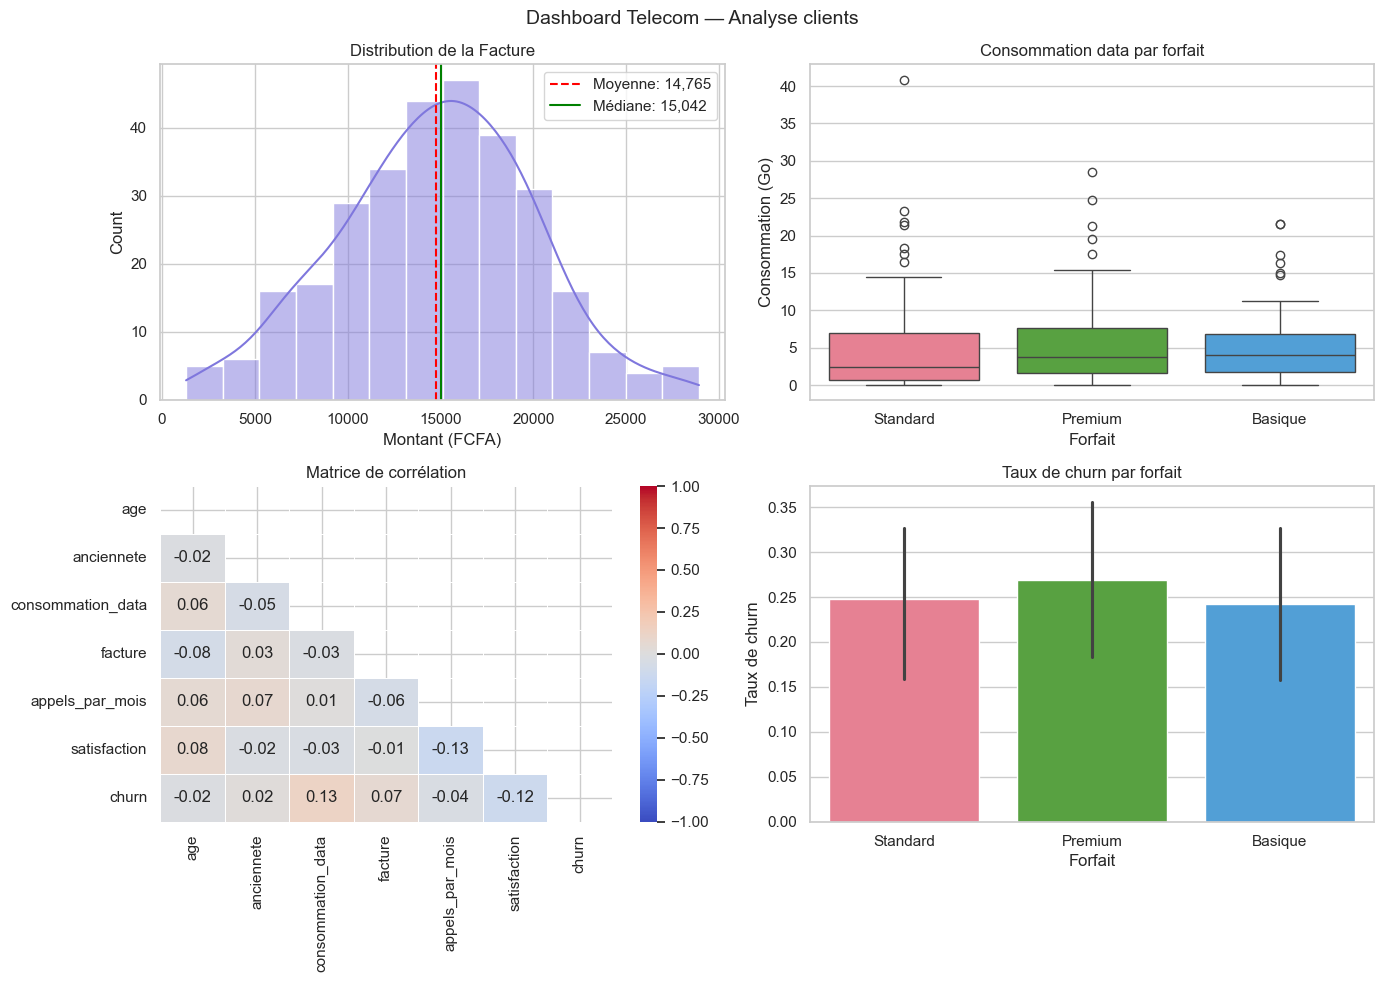

In [68]:
np.random.seed(42)
n = 300

df_telecom = pd.DataFrame({
    "client_id": range(1, n+1),
    "age": np.random.randint(18, 70, n),
    "anciennete": np.random.randint(1, 15, n),
    "consommation_data": np.random.exponential(5, n).round(2),  # en Go
    "facture": np.random.normal(15000, 5000, n).astype(int).clip(0),
    "appels_par_mois": np.random.poisson(45, n),
    "satisfaction": np.random.randint(1, 6, n),
    "forfait": np.random.choice(["Basique", "Standard", "Premium"], n),
    "churn": np.random.choice([0, 1], n, p=[0.75, 0.25])  # 25% ont quitté
})
#1- Affiche les statistiques descriptives complètes (moyenne, médiane, écart-type, skewness, kurtosis)
liste=df_telecom[["age" ,"anciennete","consommation_data","facture","appels_par_mois","satisfaction","churn"]]
fonctions = ["mean", "median", "std", "skew", "kurt"]
stats_desc = liste.agg(fonctions).round(0)
stats_desc.index = ["Moyenne", "Médiane", "Écart-type", "Skewness", "Kurtosis"]

print("=== STATISTIQUES DESCRIPTIVE ===")
print(stats_desc.to_string())

#2-Teste la normalité de facture et consommation_data avec Shapiro-Wilk
# Test de normalité de Shapiro-Wilk de facture
colonnes = ['facture', 'consommation_data']
print("=== TEST DE NORMALITÉ (Shapiro-Wilk) ===")
for col in colonnes:
    stat, p_value = stats.shapiro(df_telecom[col].sample(30))
    print(f"Variable: {col:18} | p-value: {p_value:.4f}")
    
    if p_value > 0.05:
        print("   -> Distribution probablement normale (On ne rejette pas H0)")
    else:
        print("   -> Distribution non normale (On rejette H0)")
#3- Calcule la matrice de corrélation et identifie les relations les plus fortes
print("======= Matrice de correlation======")
df_numerique = df_telecom.select_dtypes(include=['number']).drop(columns=["client_id"])
# Calcul de la matrice de corrélation (méthode de Pearson par défaut)
corr_matrix = df_numerique.corr()
#  Créer la Heatmap (Carte de chaleur) de correlation
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            mask=mask,        #Créer un masque pour la partie supérieure
            annot=True,       # Affiche les chiffres dans les cases
            fmt=".2f",        # 2 chiffres après la virgule
            cmap='coolwarm',  # Couleur : bleu (froid/négatif) à rouge (chaud/positif)
            linewidths=0.5,   # Ajoute une fine ligne entre les cases
            vmin=-1, vmax=1)  # Fixe l'échelle de -1 à 1

plt.title("Matrice de Corrélation des variables Telecom")
plt.show()
print("====identifie les relations les plus fortes====")
print(" Tous les coefficients sont inférieurs à 0.2 en valeur absolue donc pas de forte correlation")
#4- Analyse le taux de churn par forfait — quel forfait perd le plus de clients ?
 # statistique descriptive:
stats_par_groupe = df_telecom.groupby('forfait')['churn'].agg([
    'count',   # Nombre d'individus par groupe
    'mean',    # Moyenne
    'median',  # Médiane (plus robuste aux salaires extrêmes)
    'std'      # Écart-type (dispersion)
]).round(0)

print(stats_par_groupe)
#Visualisation (Le Boxplot et le Barplot)
# Garde uniquement le barplot — c'est le bon graphique !
sns.barplot(x='forfait', y='churn', data=df_telecom,
            hue="forfait", legend=False)
plt.title("Moyenne des churn avec intervalle de confiance")
plt.show()
print("Au regard du graphique le churn est plus elevé au niveau du forfait premium donc il parait que que c'est le forfait quiperd le plus de client")

#5- Trace un dashboard avec 4 graphiques :
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution de la facture avec moyenne et médiane
sns.histplot(data=df_telecom, x="facture", kde=True,
             color="#7F77DD", ax=axes[0,0])
moyenne = df_telecom['facture'].mean()
mediane = df_telecom['facture'].median()
axes[0,0].axvline(moyenne, color='red', linestyle='--',
                  label=f'Moyenne: {moyenne:,.0f}')
axes[0,0].axvline(mediane, color='green', linestyle='-',
                  label=f'Médiane: {mediane:,.0f}')
axes[0,0].set_title('Distribution de la Facture')
axes[0,0].set_xlabel('Montant (FCFA)')
axes[0,0].legend()

# 2. Boxplot consommation data par forfait
sns.boxplot(data=df_telecom, x="forfait", y="consommation_data",
            hue="forfait", legend=False,
            palette="husl", ax=axes[0,1])
axes[0,1].set_title("Consommation data par forfait")
axes[0,1].set_xlabel("Forfait")
axes[0,1].set_ylabel("Consommation (Go)")

# 3. Heatmap de corrélation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5,
            ax=axes[1,0],
            vmin=-1, vmax=1)
axes[1,0].set_title("Matrice de corrélation")

# 4. Taux de churn par forfait
sns.barplot(x='forfait', y='churn', data=df_telecom,
            hue="forfait", legend=False,
            palette="husl", ax=axes[1,1])
axes[1,1].set_title("Taux de churn par forfait")
axes[1,1].set_xlabel("Forfait")
axes[1,1].set_ylabel("Taux de churn")

plt.suptitle("Dashboard Telecom — Analyse clients", fontsize=14)
plt.tight_layout()
plt.show()


<h5>Ton travail :</h5>
<p>
 <ol type="1">   
<li>Affiche les statistiques descriptives complètes (moyenne, médiane, écart-type, skewness, kurtosis)</li>
<li>Teste la normalité de facture et consommation_data avec Shapiro-Wilk</li>
<li>Calcule la matrice de corrélation et identifie les relations les plus fortes</li>
<li>Analyse le taux de churn par forfait — quel forfait perd le plus de clients ?</li>
<li>Trace un dashboard avec 4 graphiques :
    <ul>
     <li>Distribution de la facture avec moyenne et médiane </li>
     <li>Boxplot de la consommation data par forfait</li>
     <li>Heatmap de corrélation</li>
     <li>Taux de churn par forfait</li>
    </ul>
</li>
</ol>
</p>

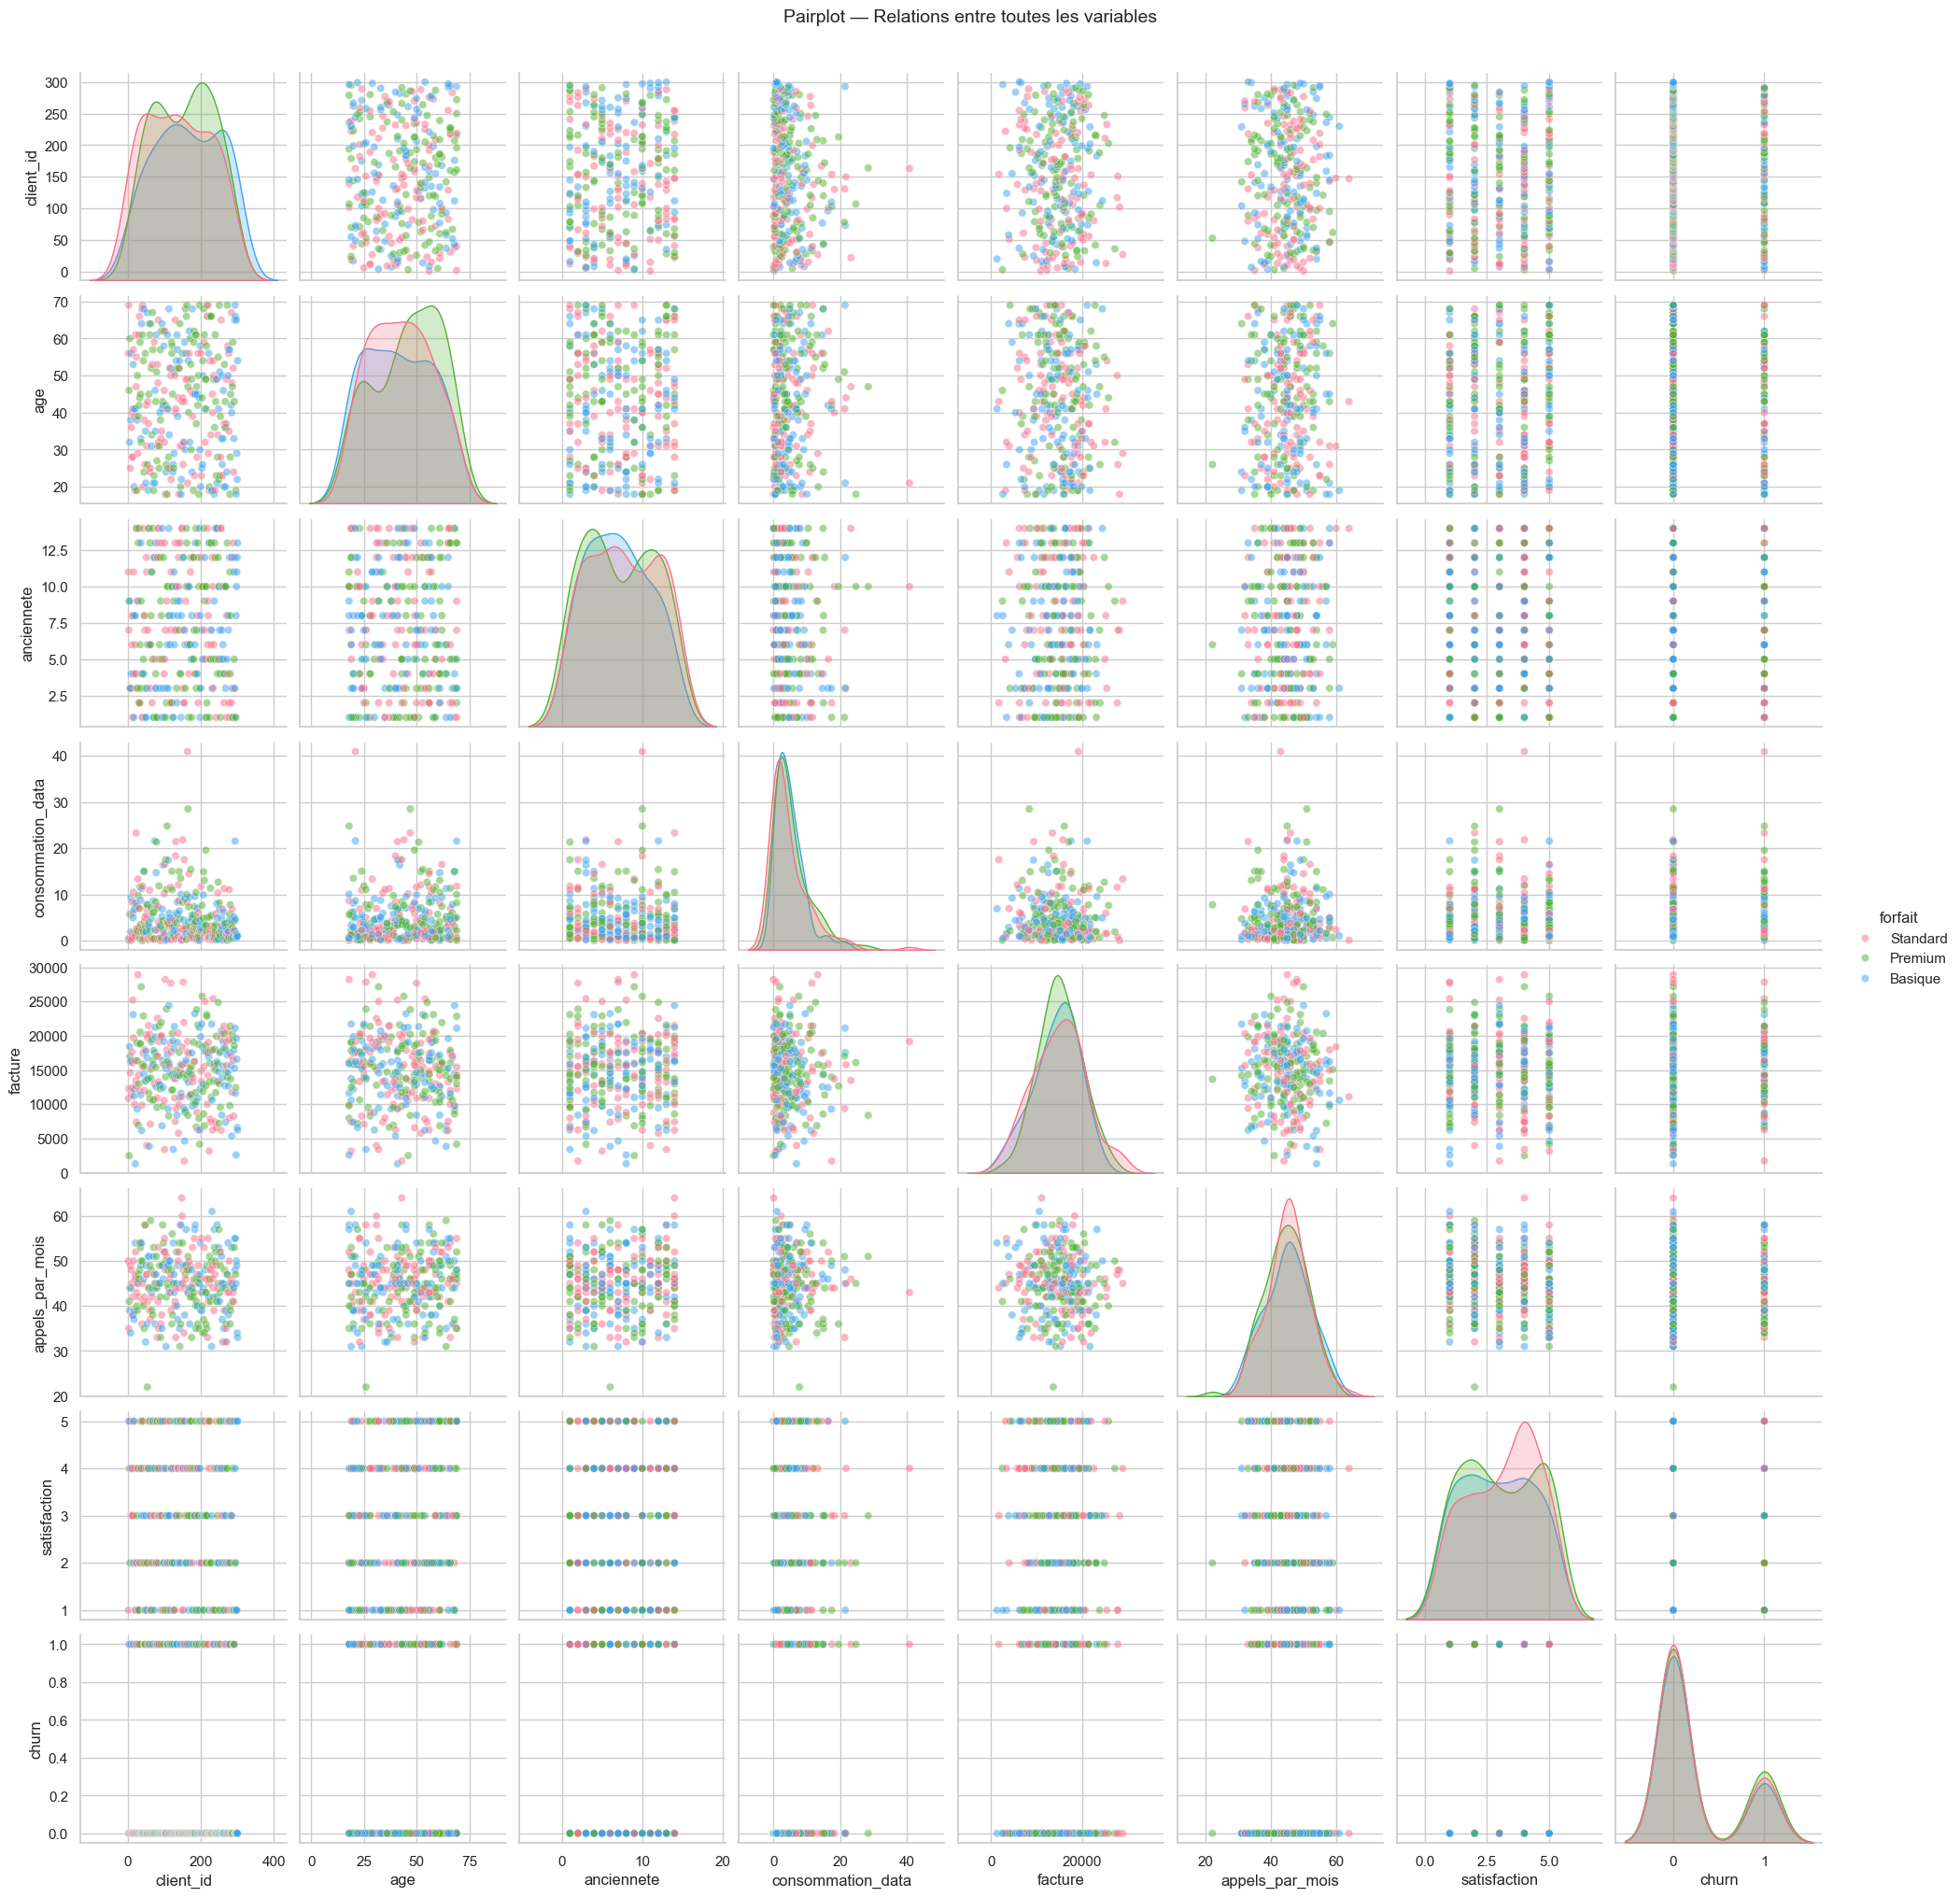

In [56]:
g = sns.pairplot(df_telecom[liste1], 
                 hue="forfait",
                 palette="husl",
                 diag_kind="kde",
                 plot_kws={"alpha": 0.5})

g.fig.suptitle("Pairplot — Relations entre toutes les variables",y=1.02, fontsize=14)
plt.show()